In [56]:
%pip install undetected-chromedriver 

Note: you may need to restart the kernel to use updated packages.


In [57]:
# 104-OK
# 參考 New_Dcard_Crawler

from selenium.webdriver.common.by import By
from selenium import webdriver
from time import sleep
import undetected_chromedriver as uc
import pandas as pd
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# (1) 設計滾動次數，input()結果為字串須轉型成int
scroll_wanted = int(input('請輸入所要滾動的次數: '))

# (2) 啟動uc瀏覽器，傳入欲爬取對象的網址，並進行視窗切換確認。
# 設定瀏覽器選項，停用快取（選擇性）
options = uc.ChromeOptions()
options.add_argument("--disable-cache")
driver = uc.Chrome(options=options)

# 開啟新分頁
driver.execute_script("window.open('https://www.104.com.tw/jobs/search/?jobsource=m_index_job_n&ro=1&utm_medium=cweb_job_logout&utm_source=104', '_blank')")
sleep(3)

# 確保切換到新分頁
driver.switch_to.window(driver.window_handles[-1])

# 確保載入目標網址
driver.get('https://www.104.com.tw/jobs/search/?jobsource=m_index_job_n&ro=1&utm_medium=cweb_job_logout&utm_source=104')

# 確認目前 URL，檢查是否正確切換到 104 網站
print("目前視窗的 URL:", driver.current_url)

# (3) 準備資料存放的List
name = []
link = []
company = []
location = []
experience = []
education = []
salary = []
work = []

# (4) 爬蟲主程式設計
for current_time in range(1, scroll_wanted + 1):
    sleep(2)

    # 等待頁面加載完成後定位所需的標籤
    articles = driver.find_elements(By.CLASS_NAME, 'vue-recycle-scroller__item-view.recycle-scroller--item')

    for each_article in articles:
        try:
            # 爬取職缺標題、連結
            title = each_article.find_element(By.TAG_NAME, 'h2').text
            href = each_article.find_element(By.TAG_NAME, 'a').get_attribute('href')
            
            # 使用顯式等待確保公司名稱元素加載完成
            author = WebDriverWait(each_article, 10).until(
                EC.presence_of_element_located((By.CSS_SELECTOR, '.info-company > a'))
            ).text
            
            # 爬取地區、經歷、學歷、薪水
            loc = each_article.find_element(By.CSS_SELECTOR, 'a[data-gtm-joblist*="地區"]').text
            exp = each_article.find_element(By.CSS_SELECTOR, 'a[data-gtm-joblist*="經歷"]').text
            edu = each_article.find_element(By.CSS_SELECTOR, 'a[data-gtm-joblist*="學歷"]').text
            sal = each_article.find_element(By.CSS_SELECTOR, 'a[data-gtm-joblist*="薪資"]').text

            # 工作內容
            content = WebDriverWait(each_article, 10).until(
                EC.presence_of_element_located((By.CSS_SELECTOR, '.info-description'))
            ).text

            name.append(title)
            link.append(href)
            company.append(author)
            location.append(loc)
            experience.append(exp)
            education.append(edu)
            salary.append(sal)
            work.append(content)

        except Exception as e:
            # 捕捉並列印錯誤以便排查
            print("錯誤:", e)

    print("當前滾動進度", current_time, "/", scroll_wanted)

    # 執行滾動
    js = "window.scrollTo(0, document.body.scrollHeight);"
    driver.execute_script(js)

    # 等待頁面加載
    sleep(3)

# 建立 DataFrame
df = pd.DataFrame({
    '職缺': name,
    '連結': link,
    '公司': company,
    '地區': location,
    '經歷': experience,
    '學歷': education,
    '薪水': salary,
    '工作內容': work
})

# 輸出資料
print(df)

# 儲存為 CSV 檔案（選擇性）
df.to_csv("104_jobs.csv", index=False, encoding="utf-8-sig")

# 選擇性關閉瀏覽器
driver.quit()

請輸入所要滾動的次數:  5


目前視窗的 URL: https://www.104.com.tw/jobs/search/?jobsource=m_index_job_n&ro=1&utm_medium=cweb_job_logout&utm_source=104
當前滾動進度 1 / 5
當前滾動進度 2 / 5
錯誤: Message: no such element: Unable to locate element: {"method":"css selector","selector":"a[data-gtm-joblist*="薪資"]"}
  (Session info: chrome=131.0.6778.205); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#no-such-element-exception
Stacktrace:
	GetHandleVerifier [0x0053EC13+23731]
	(No symbol) [0x004CC394]
	(No symbol) [0x003ABE63]
	(No symbol) [0x003EFCE6]
	(No symbol) [0x003EFF2B]
	(No symbol) [0x003E5A81]
	(No symbol) [0x00411EA4]
	(No symbol) [0x003E59A4]
	(No symbol) [0x004120F4]
	(No symbol) [0x0042B46E]
	(No symbol) [0x00411BF6]
	(No symbol) [0x003E3F35]
	(No symbol) [0x003E4EBD]
	GetHandleVerifier [0x0081F0D3+3039603]
	GetHandleVerifier [0x00832DEA+3120778]
	GetHandleVerifier [0x0082B592+3089970]
	GetHandleVerifier [0x005D43B0+635984]
	(No symbol) [0x004D4DCD]
	(

In [58]:
# 資料處理

import openpyxl #控制Excel之用
import pandas as pd

# 讀取 CSV 檔案
csv_file = "104_jobs.csv"  # CSV 檔案名稱
xlsx_file = "104_jobs.xlsx"  # 輸出的 XLSX 檔案名稱

try:
    # 使用 pandas 讀取 CSV 檔案
    df = pd.read_csv(csv_file, encoding="utf-8-sig")
    
    # 儲存為 Excel 檔案
    df.to_excel(xlsx_file, index=False, engine='openpyxl')
    
    print(f"成功將 {csv_file} 轉換為 {xlsx_file}")
except Exception as e:
    print(f"轉換失敗: {e}")

成功將 104_jobs.csv 轉換為 104_jobs.xlsx


In [59]:
%pip install customtkinter

Note: you may need to restart the kernel to use updated packages.


In [60]:
pip install pandas openpyxl

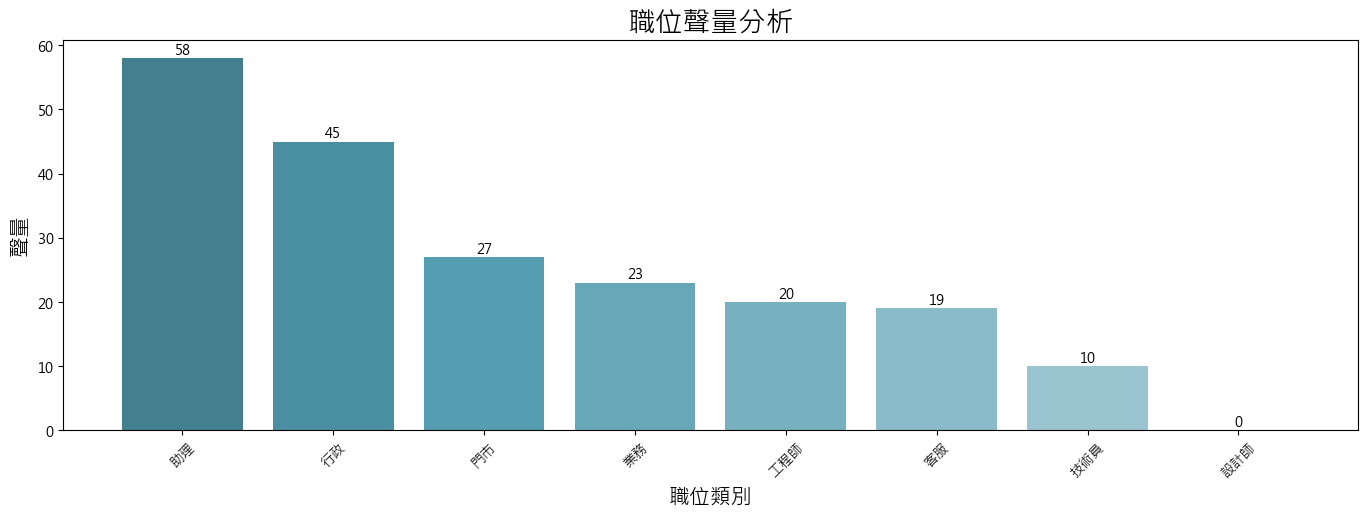

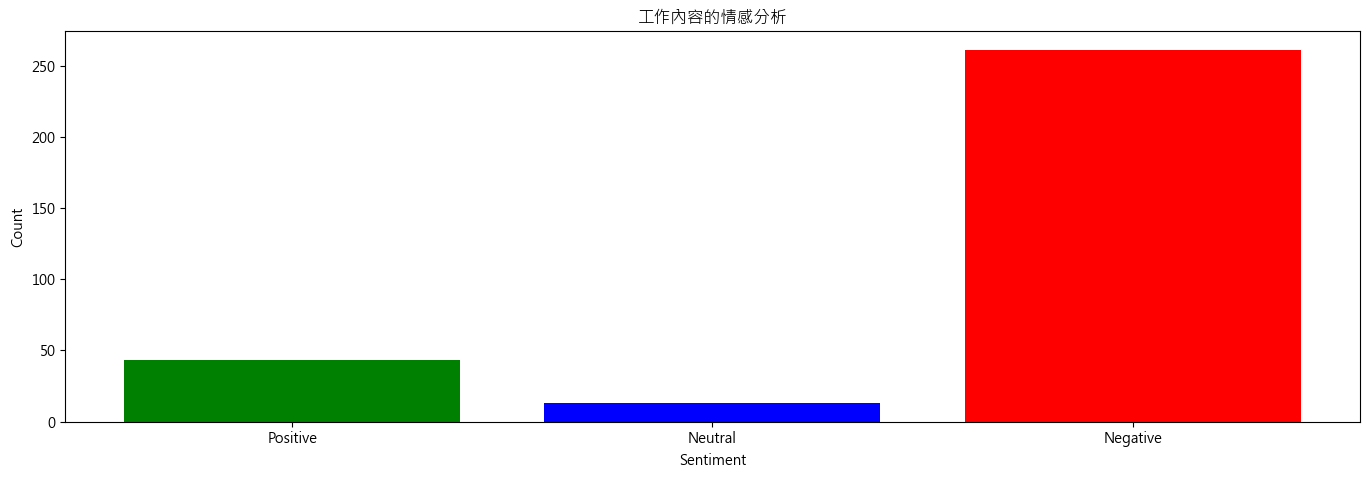

In [61]:
# 參考 GPT簡易客服 + Excel + UI & PTT爬蟲+情感+UI(視窗) & 汽車廠牌聲量分析(聲量分析)
import customtkinter as ctk
from tkinter import ttk
from tkinter import messagebox
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from snownlp import SnowNLP
from collections import Counter

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 設定字型避免亂碼

def read_excel():
    path = "104_jobs.xlsx"
    df = pd.read_excel(path)
    cols = df.columns.tolist()

    tree = ttk.Treeview(frame, column=cols, show="headings")
    for col_name in cols:
        tree.heading(col_name, text=col_name)
        tree.pack()

    for _, row in df.iterrows():
        tree.insert('', ctk.END, values=row.tolist())

def volume():
    path = "104_jobs.xlsx"
    df = pd.read_excel(path)

    job_categories = {
        "工程師": ["工程師", "engineer", "Engineer"],
        "技術員": ["技術員", "Technician", "technician"],
        "行政": ["行政", "Admin", "admin"],
        "業務": ["業務", "Sales", "sales"],
        "客服": ["客服", "Customer Service", "customer service"],
        "門市": ["門市", "Store", "store"],
        "助理": ["助理", "Assistant", "assistant"],
        "設計師": ["設計師", "Designer", "designer"],
    }
    
    job_counts = {category: 0 for category in job_categories}

    for title in df["職缺"]:
        for category, keywords in job_categories.items():
            if any(keyword in str(title) for keyword in keywords):
                job_counts[category] += 1

    job_counts_df = pd.DataFrame(job_counts.items(), columns=["職位類別", "聲量"])
    job_counts_df = job_counts_df.sort_values(by="聲量", ascending=False)

    colorgroup1 = ['#427f8f','#4a8fa1','#559db0','#66a7b8','#77b1c0','#89bbc8','#9ac5d0','#bdd9e0','#cee3e8']

    fig, ax = plt.subplots()
    fig.set_size_inches(5, 4)  # 設置圖表大小

    ax.bar(job_counts_df["職位類別"], job_counts_df["聲量"], color=colorgroup1[:len(job_counts_df)])

    for index, data in enumerate(job_counts_df["聲量"]):
        ax.text(x=index, y=data, s=data, verticalalignment="bottom", horizontalalignment="center")

    ax.set_xlabel('職位類別', fontsize=15)
    ax.set_ylabel('聲量', fontsize=15)
    ax.set_title('職位聲量分析', fontsize=20)
    ax.set_xticks(range(len(job_counts_df["職位類別"])))
    ax.set_xticklabels(job_counts_df["職位類別"], rotation=45)

    # 清除先前的畫布（如果存在）
    for widget in plot_frame.winfo_children():
        widget.destroy()

    canvas = FigureCanvasTkAgg(fig, master=plot_frame)
    canvas.draw()
    canvas.get_tk_widget().pack(fill='both', expand=True)

def sentiment_analyze():
    path = "104_jobs.xlsx"
    df = pd.read_excel(path)
    
    if '工作內容' not in df.columns:
        messagebox.showerror("錯誤", "Excel 檔案中缺少必要欄位：'工作內容'")
        return

    # 分析情感分數與分類函數
    def analyze_sentiments(df):
        # 過濾空值和非文字值
        df = df[df['工作內容'].notna()].copy()  # 去掉空值，並創建副本
        df.loc[:, '工作內容'] = df['工作內容'].astype(str)  # 確保所有值為文字 # 使用.loc明確定位並修改，避免觸發警告

        df.loc[:, 'Sentiment'] = df['工作內容'].apply(lambda x: SnowNLP(x).sentiments)
    
        def sentiment_category(score):
            if score > 0.7:
                return "Positive"
            elif score >= 0.3:
                return "Neutral"
            else:
                return "Negative"
    
        df.loc[:, 'Sentiment Category'] = df['Sentiment'].apply(sentiment_category)
        return df

    df = analyze_sentiments(df)
    sentiments = df['Sentiment Category'].value_counts()

    # 清除先前的畫布（如果存在）
    for widget in plot_frame.winfo_children():
        widget.destroy()

    fig, ax = plt.subplots()
    fig.set_size_inches(5, 4)  # 設置圖表大小

    categories = ['Positive', 'Neutral', 'Negative']
    counts = [sentiments.get(cat, 0) for cat in categories]
    
    ax.bar(categories, counts, color=['green', 'blue', 'red'])
    ax.set_xlabel('Sentiment')
    ax.set_ylabel('Count')
    ax.set_title('工作內容的情感分析')

    canvas = FigureCanvasTkAgg(fig, master=plot_frame)
    canvas.draw()
    canvas.get_tk_widget().pack(fill='both', expand=True)

background = ctk.CTk()
background.geometry('750x800')
background.title('資料分析')

upper_label = ctk.CTkLabel(background, text='下方內容為讀取自Excel資料', font=ctk.CTkFont(size=15, weight='bold'))
upper_label.pack(padx=(0, 280), pady=(5, 2))

frame = ctk.CTkFrame(background)
frame.pack(fill='x', padx=100)

button1 = ctk.CTkButton(background, text="讀取Excel", command=read_excel, fg_color='green')
button1.pack(padx=(0, 400), pady=(5, 5))

plot_frame = ctk.CTkFrame(background)
plot_frame.pack(fill='both', expand=True, padx=100, pady=(10, 10))

button2 = ctk.CTkButton(background, text="聲量分析", command=volume, fg_color='blue')
button2.pack(padx=(0, 400), pady=(5, 5))

button3 = ctk.CTkButton(background, text="情感分析", command=sentiment_analyze, fg_color='orange')
button3.pack(padx=(0, 400), pady=(5, 5))

button4 = ctk.CTkButton(background, text="離開", command=background.destroy, fg_color='red')
button4.pack(padx=(0, 400), pady=(5, 5))

background.mainloop()

In [27]:
#1111-備用
from selenium import webdriver
from selenium.webdriver.common.by import By
from time import sleep

# 啟動瀏覽器
driver = webdriver.Chrome()
driver.get("https://happiness.1111.com.tw/vacancies")

# 滾動次數
scroll_wanted = 3

# 存放職缺資料
name = []
link = []
company = []

for current_time in range(1, scroll_wanted + 1):
    sleep(3)  # 滾動後等待網站加載

    # 抓取職缺條目
    articles = driver.find_elements(By.CSS_SELECTOR, 'div[data-v-54592daa].cut-corner-border.grid')

    for each_article in articles:
        try:
            # 職缺標題
            title = each_article.find_element(By.CSS_SELECTOR, 'div.text-overflow-2.text-xl.font-bold').text
            # 職缺連結
            href = each_article.find_element(By.CSS_SELECTOR, 'a[href*="job"]').get_attribute('href')
            # 公司名稱
            author = each_article.find_element(By.CSS_SELECTOR, 'a[href*="corp"]').text

            name.append(title)
            link.append(href)
            company.append(author)

        except Exception as e:
            print("錯誤:", e)

    print(f"當前滾動進度 {current_time} / {scroll_wanted}")

    # 執行滾動
    js = "window.scrollTo(0, document.body.scrollHeight);"
    driver.execute_script(js)

# 確認資料
import pandas as pd

df = pd.DataFrame({
    "職缺": name,
    "連結": link,
    "公司": company
})

print(df)

# 關閉瀏覽器
driver.quit()


NoSuchWindowException: Message: no such window: target window already closed
from unknown error: web view not found
  (Session info: chrome=131.0.6778.205)
Stacktrace:
	GetHandleVerifier [0x00007FF7907AFB05+28789]
	(No symbol) [0x00007FF7907186E0]
	(No symbol) [0x00007FF7905B592A]
	(No symbol) [0x00007FF79058F505]
	(No symbol) [0x00007FF790636477]
	(No symbol) [0x00007FF79064EF42]
	(No symbol) [0x00007FF79062F1E3]
	(No symbol) [0x00007FF7905FA938]
	(No symbol) [0x00007FF7905FBAA1]
	GetHandleVerifier [0x00007FF790AE933D+3410093]
	GetHandleVerifier [0x00007FF790AFE7DD+3497293]
	GetHandleVerifier [0x00007FF790AF2A73+3448803]
	GetHandleVerifier [0x00007FF790877BBB+848171]
	(No symbol) [0x00007FF790723C3F]
	(No symbol) [0x00007FF79071F6E4]
	(No symbol) [0x00007FF79071F87D]
	(No symbol) [0x00007FF79070ED49]
	BaseThreadInitThunk [0x00007FF8C8D7259D+29]
	RtlUserThreadStart [0x00007FF8CA1CAF38+40]
